<a href="https://colab.research.google.com/github/asiddiqha/ai-workbench/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ==========================================================
# PRINCIPAL COMPONENT ANALYSIS (PCA)
# Followed by Logistic Regression Classification
# ==========================================================

# ----------------------------------------------------------
# STEP 1 : Import Required Libraries
# ----------------------------------------------------------

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ----------------------------------------------------------
# STEP 2 : Load Dataset
# ----------------------------------------------------------

df = pd.read_excel("PCA.xlsx")

df.head()

,Employee_ID,Age,Experience_Years,Monthly_Salary,Projects_Completed,Training_Hours,Performance_Score,Leaves_Taken,Target
0,E001,22,1,25000,2,15,60,10,Low
1,E002,23,2,27000,3,18,62,9,Low
2,E003,24,2,29000,3,20,65,8,Low
3,E004,25,3,32000,4,22,68,7,Medium
4,E005,26,4,35000,5,25,70,6,Medium


In [5]:
# ----------------------------------------------------------
# STEP 3 : Basic Information
# ----------------------------------------------------------

print("Shape :", df.shape)

print("\nInformation")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows :", df.duplicated().sum())

Shape : (30, 9)

Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         30 non-null     object
 1   Age                 30 non-null     int64 
 2   Experience_Years    30 non-null     int64 
 3   Monthly_Salary      30 non-null     int64 
 4   Projects_Completed  30 non-null     int64 
 5   Training_Hours      30 non-null     int64 
 6   Performance_Score   30 non-null     int64 
 7   Leaves_Taken        30 non-null     int64 
 8   Target              30 non-null     object
dtypes: int64(7), object(2)
memory usage: 2.2+ KB

Missing Values
Employee_ID           0
Age                   0
Experience_Years      0
Monthly_Salary        0
Projects_Completed    0
Training_Hours        0
Performance_Score     0
Leaves_Taken          0
Target                0
dtype: int64

Duplicate Rows : 0


In [6]:
# ----------------------------------------------------------
# STEP 4 : Statistical Summary
# ----------------------------------------------------------

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,30.0,36.500000,8.803408,22.0,29.25,36.5,43.75,51.0
Experience_Years,30.0,14.566667,8.696743,1.0,7.25,14.5,21.75,29.0
Monthly_Salary,30.0,76600.000000,34299.492305,25000.0,47000.00,76000.0,105000.00,134000.0
Projects_Completed,30.0,12.166667,6.237171,2.0,7.25,12.0,17.75,22.0
Training_Hours,30.0,50.166667,20.581350,15.0,32.75,51.0,67.50,82.0
Performance_Score,30.0,87.066667,12.835654,60.0,78.50,91.5,98.00,100.0
Leaves_Taken,30.0,2.466667,3.014143,0.0,0.00,1.0,4.00,10.0


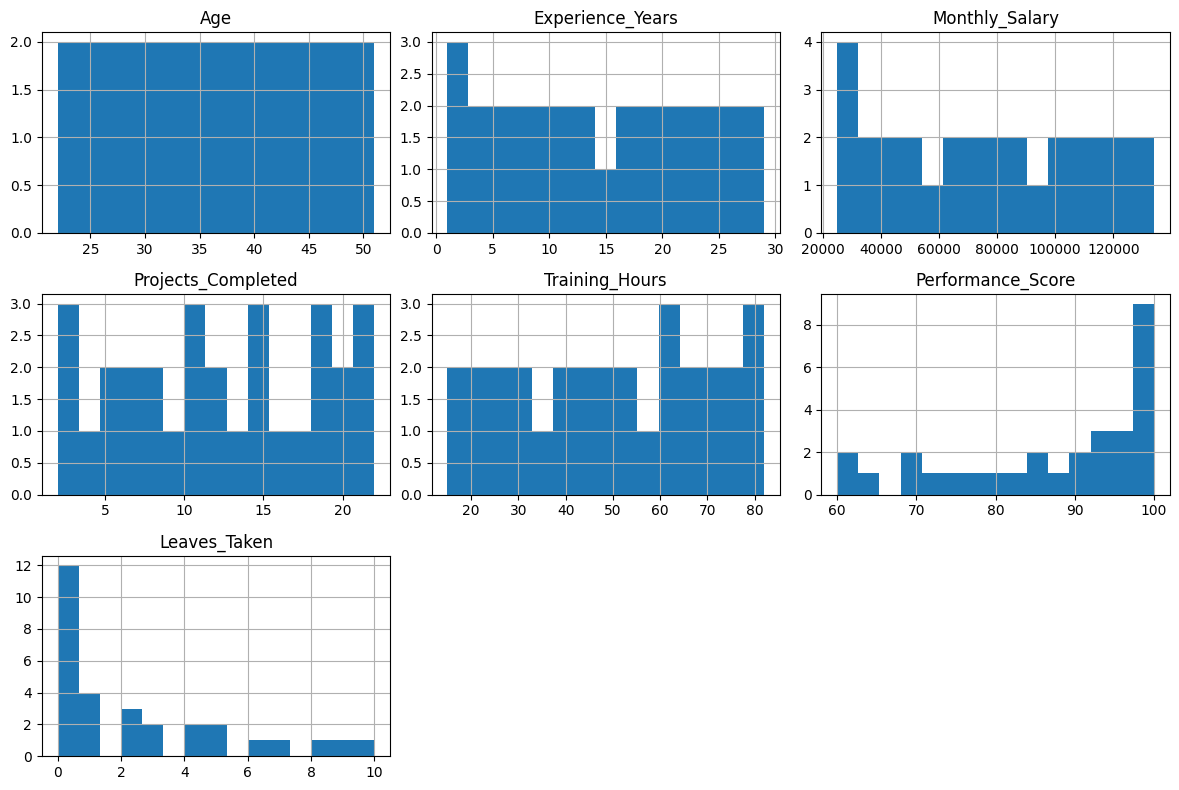

In [7]:
# ----------------------------------------------------------
# STEP 5 : Histograms
# ----------------------------------------------------------

df.hist(figsize=(12,8), bins=15)

plt.tight_layout()

plt.show()

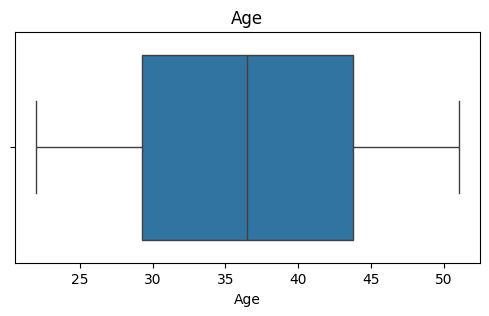

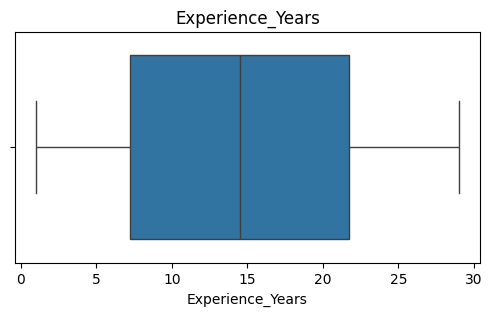

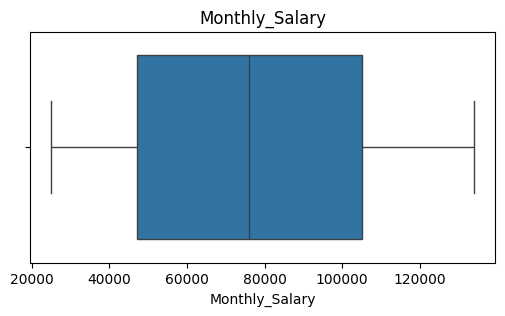

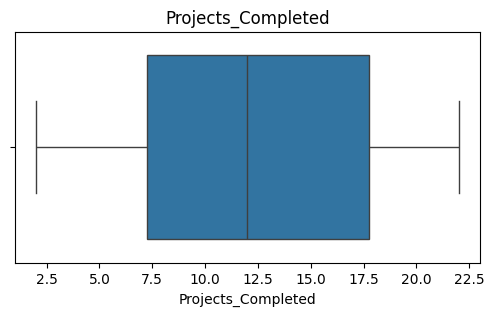

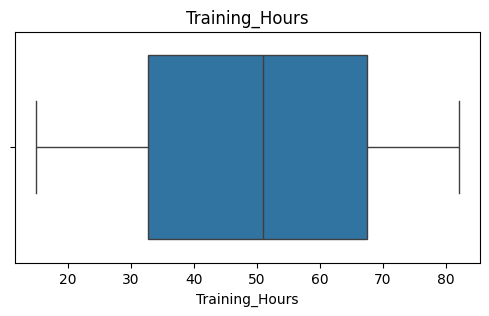

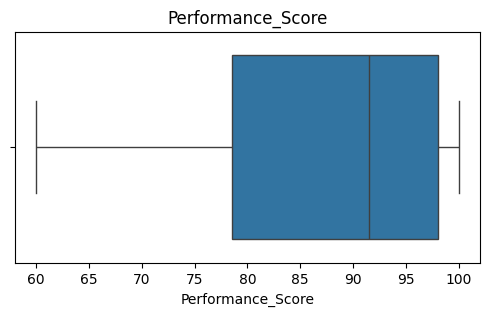

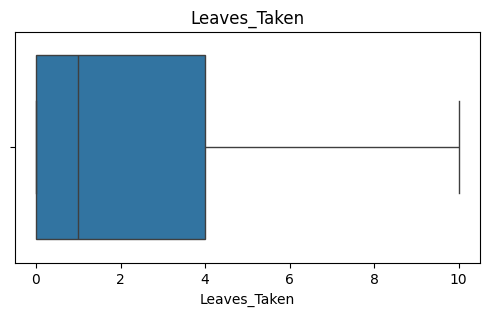

In [8]:
# ----------------------------------------------------------
# STEP 6 : Boxplots
# ----------------------------------------------------------

numerical_columns = df.select_dtypes(include=np.number).columns

for column in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

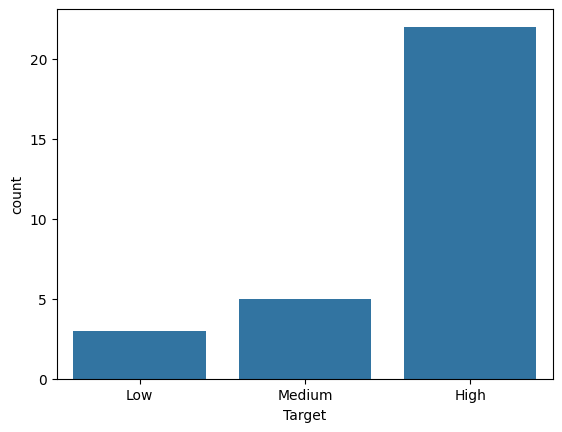

Target
High      22
Medium     5
Low        3
Name: count, dtype: int64


In [9]:
# ----------------------------------------------------------
# STEP 7 : Target Distribution
# ----------------------------------------------------------

sns.countplot(data=df, x="Target")

plt.show()

print(df["Target"].value_counts())

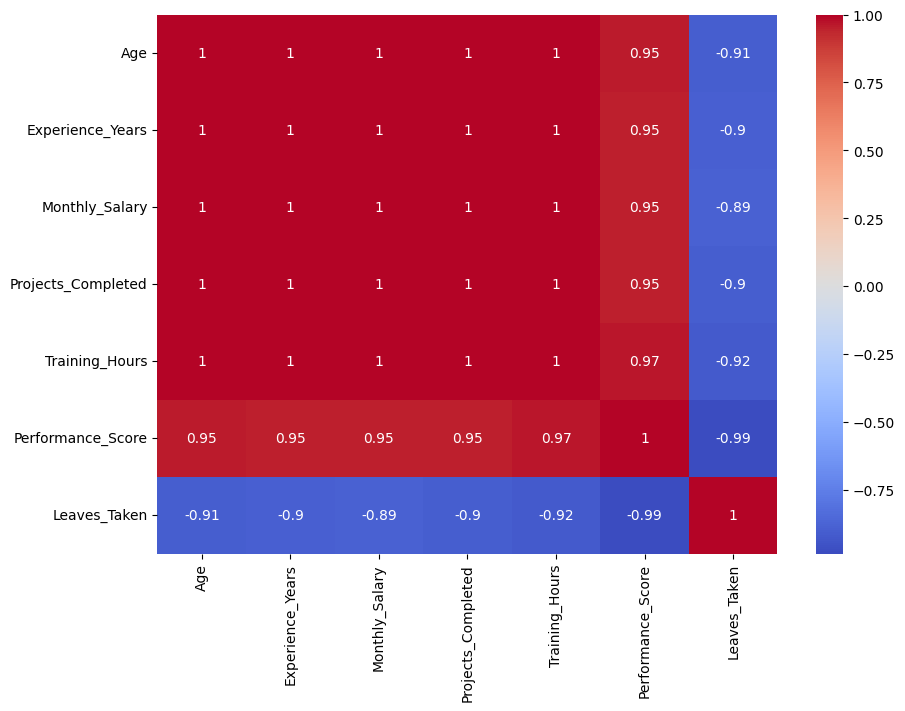

In [10]:
# ----------------------------------------------------------
# STEP 8 : Correlation Matrix
# ----------------------------------------------------------

plt.figure(figsize=(10,7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

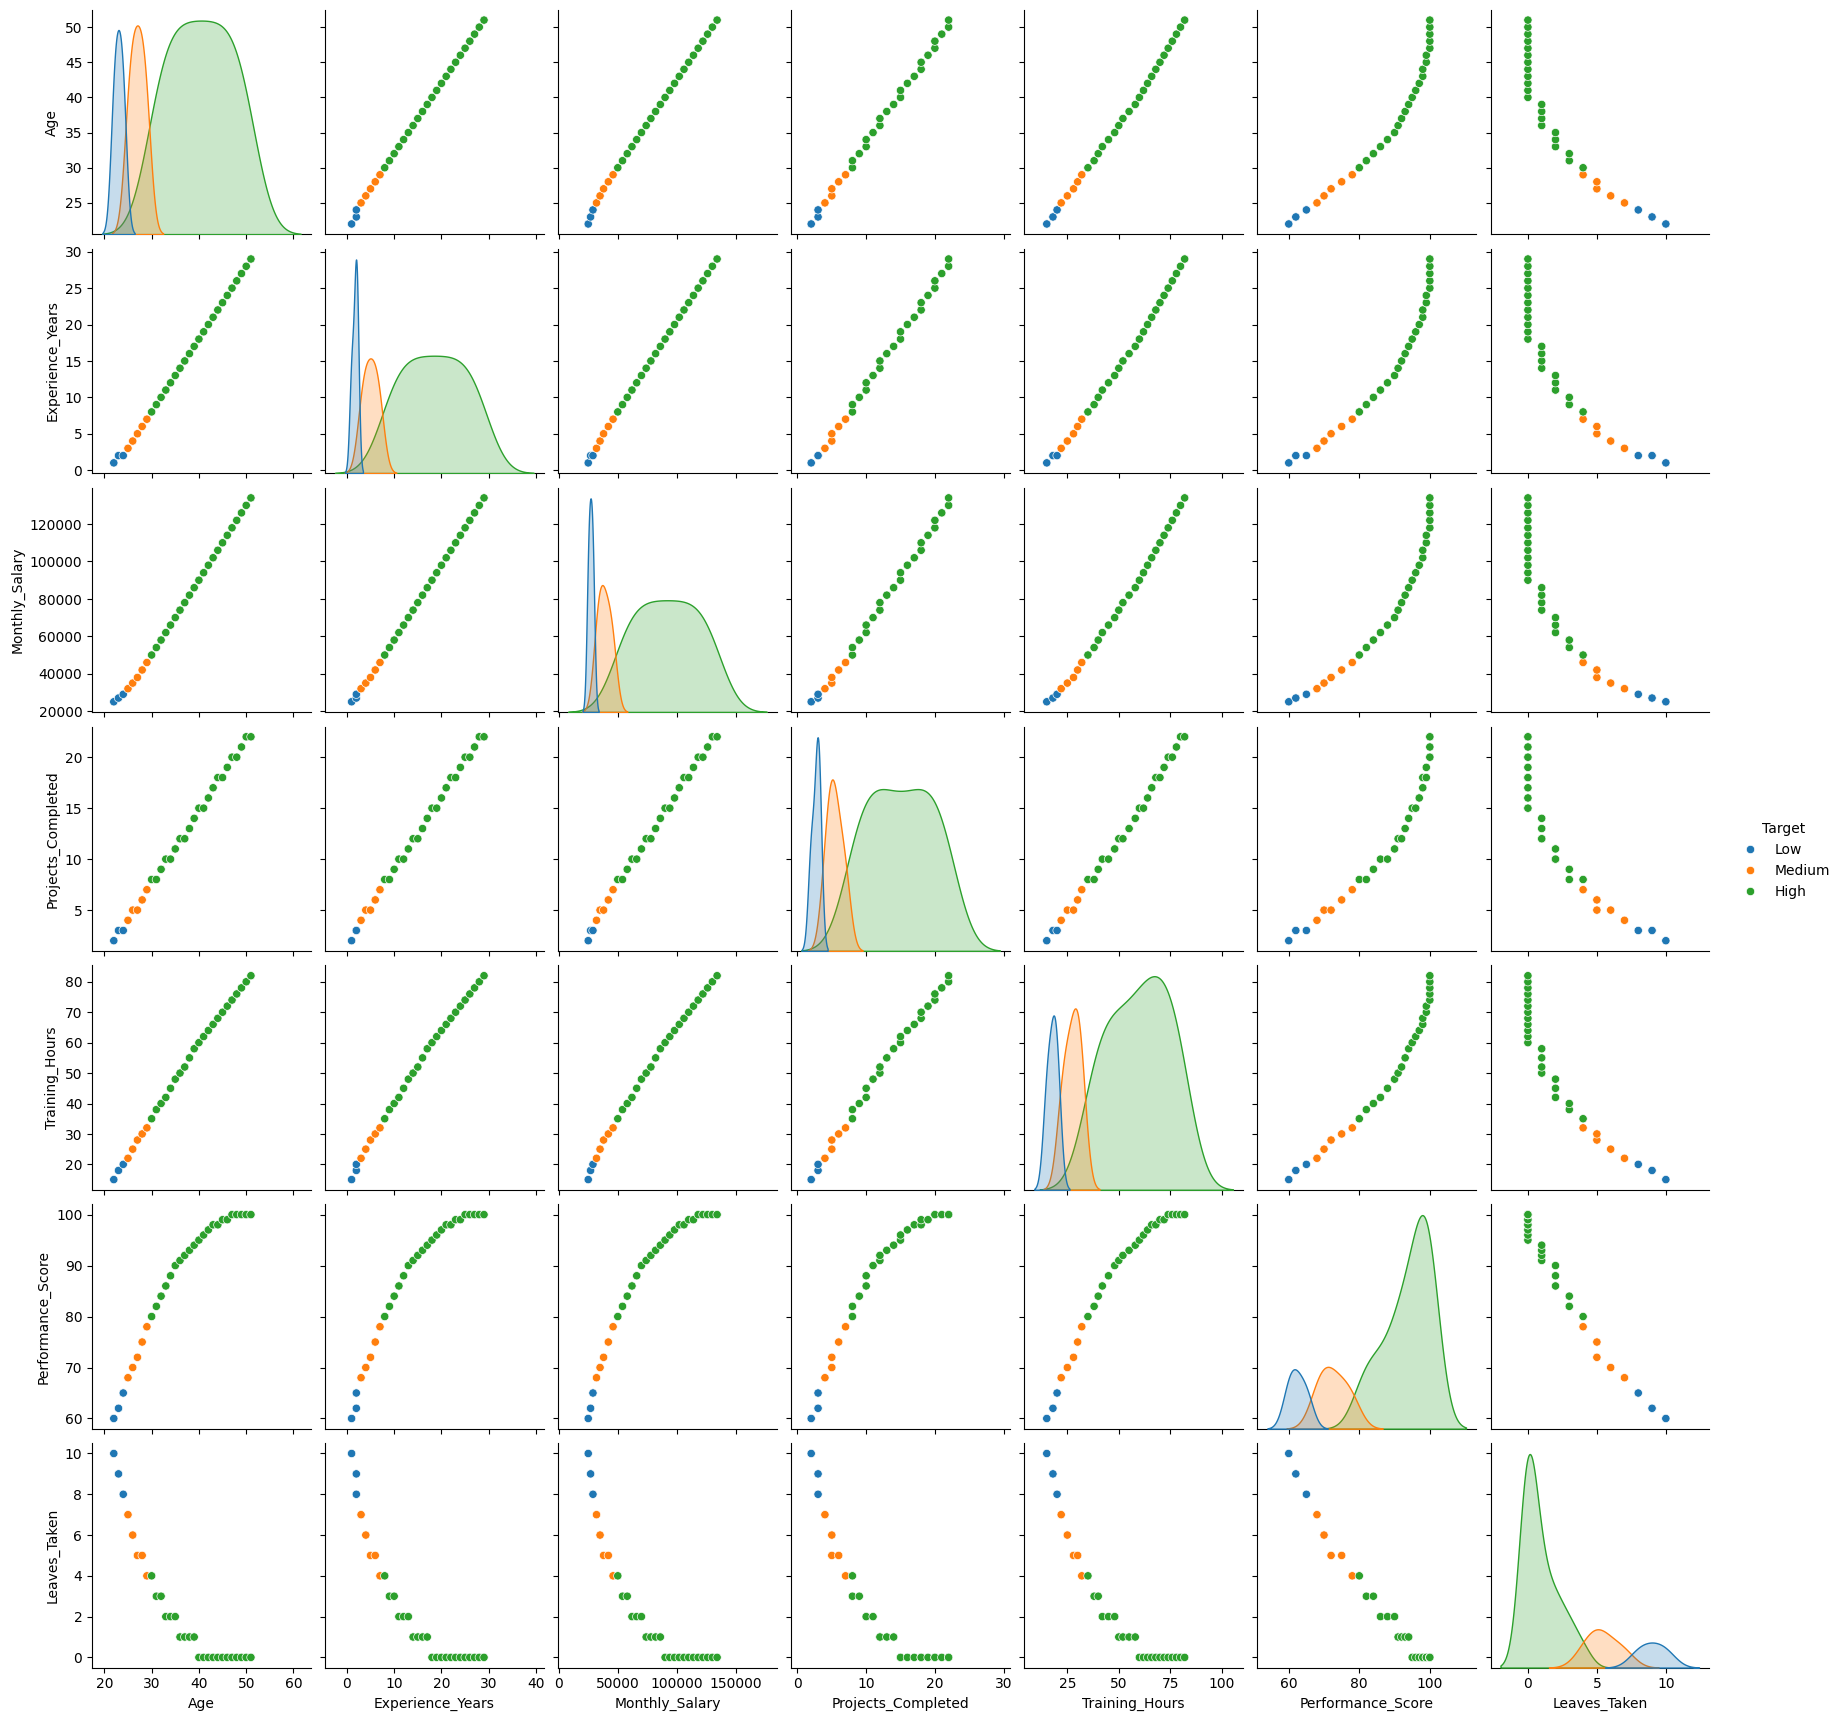

In [11]:
# ----------------------------------------------------------
# STEP 9 : Pairplot
# ----------------------------------------------------------

sns.pairplot(df, hue="Target")

plt.show()

In [12]:
# ----------------------------------------------------------
# STEP 10 : Feature Engineering
# ----------------------------------------------------------

# Remove Employee ID

df.drop("Employee_ID", axis=1, inplace=True)

# Encode Target

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["Target"] = encoder.fit_transform(df["Target"])

df.head()

,Age,Experience_Years,Monthly_Salary,Projects_Completed,Training_Hours,Performance_Score,Leaves_Taken,Target
0,22,1,25000,2,15,60,10,1
1,23,2,27000,3,18,62,9,1
2,24,2,29000,3,20,65,8,1
3,25,3,32000,4,22,68,7,2
4,26,4,35000,5,25,70,6,2


In [13]:
# ----------------------------------------------------------
# STEP 11 : Feature Selection
# ----------------------------------------------------------

X = df.drop("Target", axis=1)

y = df["Target"]

print(X.shape)

print(y.shape)

(30, 7)
(30,)


In [14]:
# ----------------------------------------------------------
# STEP 12 : Train Test Split
# ----------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# ----------------------------------------------------------
# STEP 13 : Standardization
# ----------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [16]:
# ----------------------------------------------------------
# STEP 14 : Principal Component Analysis
# ----------------------------------------------------------

pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

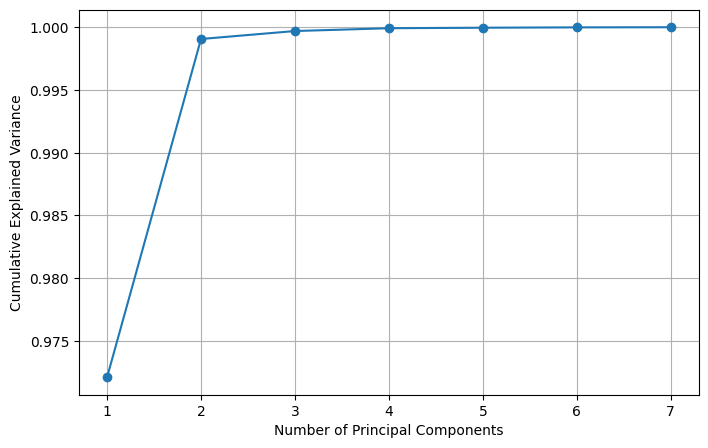

In [17]:
# ----------------------------------------------------------
# STEP 15 : Explained Variance
# ----------------------------------------------------------

variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(variance)+1),
    variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")

plt.ylabel("Cumulative Explained Variance")

plt.grid(True)

plt.show()

In [18]:
# ----------------------------------------------------------
# STEP 16 : Select Principal Components
# ----------------------------------------------------------

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

In [19]:
# ----------------------------------------------------------
# STEP 17 : Train Logistic Regression
# ----------------------------------------------------------

model = LogisticRegression()

model.fit(X_train_pca, y_train)

LogisticRegression()

In [20]:
# ----------------------------------------------------------
# STEP 18 : Prediction
# ----------------------------------------------------------

y_pred = model.predict(X_test_pca)

In [21]:
# ----------------------------------------------------------
# STEP 19 : Model Evaluation
# ----------------------------------------------------------

print("Accuracy :", accuracy_score(y_test, y_pred))

print("\nClassification Report")

print(classification_report(y_test, y_pred))

Accuracy : 0.8333333333333334

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           2       0.00      0.00      0.00         0

    accuracy                           0.83         6
   macro avg       0.50      0.42      0.45         6
weighted avg       1.00      0.83      0.91         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


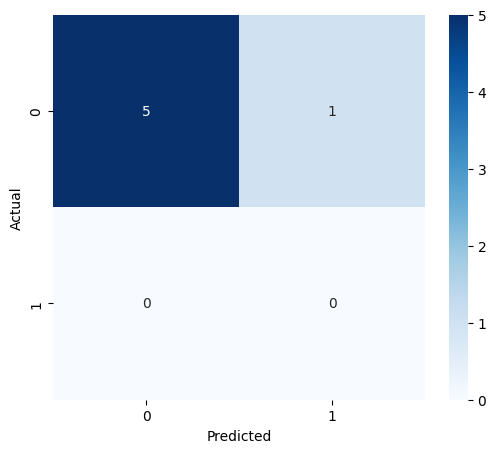

In [22]:
# ----------------------------------------------------------
# STEP 20 : Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()